# Report 4

# Task 1
## Exercise 1

##### Compute the number of TCP connections whose client is “local” and are directed towards the services matching with “*facebook.com”, separated for each complete service name. Then plot them as a barplot, ordered by decreasing number of TCP connections (if they are more than 20, plot the top-20).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#defining a function that returns the service name
def check_hostname(x):
    if x['fqdn:127'] != "-":
        return x['fqdn:127']
    elif x['http_hostname:131'] != "-":
        return x['http_hostname:131']
    elif x['c_tls_SNI:116'] != "-":
        return x['c_tls_SNI:116']
    elif x['s_tls_SCN:117'] != "-":
        return x['s_tls_SCN:117']
    else:
        return "-"

In [7]:
#reading the csv file
df = pd.read_csv("Report 4/log_tcp_complete.xz", sep= " ")

#filtering dataframe by local client
df_local = df[df["c_isint:38"]==1]

#adding a coloumn "hostname"
df_local["hostname"] = df_local.apply(check_hostname, axis=1)

#filtering df by the "str_fb" hostname
str_fb="/*facebook.com"
df_facebook = df_local[df_local["hostname"].str.contains(str_fb)]

#counting number of connections separated for each complete service name
fb_client = df_facebook.groupby("hostname").size().sort_values(ascending=False)


C:\Users\Jonny\AppData\Local\Temp/ipykernel_22220/14404929.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_local["hostname"] = df_local.apply(check_hostname, axis=1)


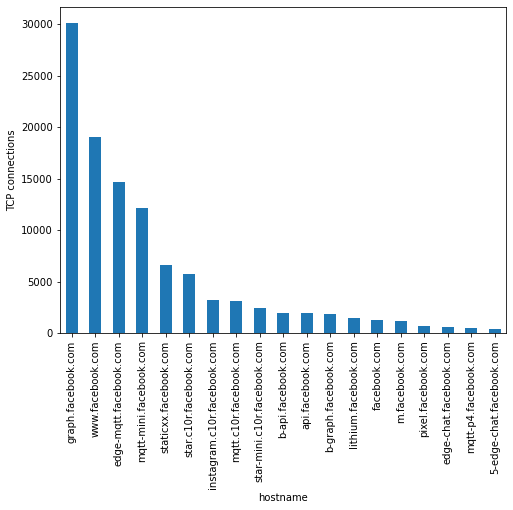

In [8]:
#plotting the first 20
barplot = fb_client[0:19].plot(kind="bar", figsize=(8, 6), ylabel="TCP connections")

## Exercise 1a

#### What happens if you match "\*facebook\*" instead of "*facebook.com"? discuss the usefulness of the regex concept

Using a regex is very useful in string processing in general, because they allow to specify a specific pattern to search in the document or stream we are considering. For instance, it could be used to verify the correctness of a certain string like an email address, which format has to be compliant to a certain structure. In this case, using a regex like "\*facebook.com" will give all the strings ending with that substring, while if we consider "\*facebook\*" we have all the possible strings containing "facebook" at any position, resulting in a wider set of strings. 

## Exercise 2

#### What are the top-15 most used services in general (without any filter on local client or service), in terms of TCP connections? Plot them as a barplot, ordered by decreasing number of TCP connections.

In [9]:
#adding a "service" coloumn
df["service"] = df.apply(check_hostname, axis=1)

#counting number of connections for each separated service
services_count = df[df["service"]!="-"].groupby("service").size().sort_values(ascending=False)

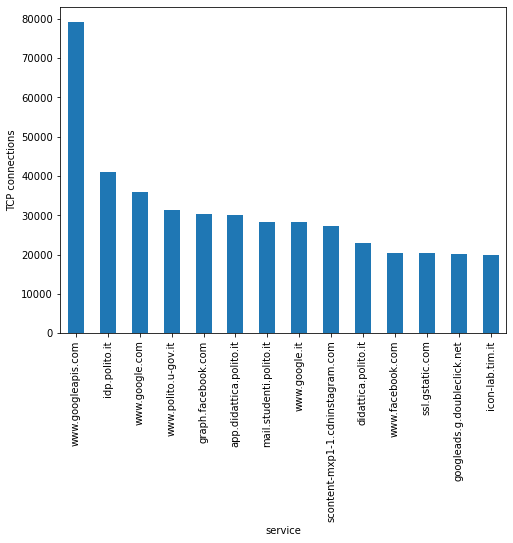

In [10]:
#plotting the top 15 most used
barplot = services_count[0:14].plot(kind="bar", figsize=(8, 6), ylabel="TCP connections")

## Exercise 2a

#### What happens if you repeat the exercise considering only HTTPS connections?
The situation does not change too much.

In [11]:
services_count_https = df[(df["service"]!="-") & (df["con_t:42"]==8192)].groupby("service").size().sort_values(ascending=False)

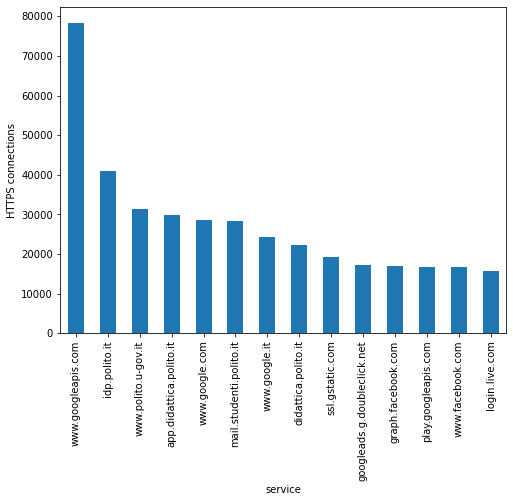

In [12]:
barplot = services_count_https[0:14].plot(kind="bar", figsize=(8, 6), ylabel="HTTPS connections")

## Exercise 3

#### Count the fraction of connections for different “connection type” (without any filter on local client or service). Plot the results as a barplot.

In [13]:
#counting the total of connection types
connection_type_tot = df.groupby("con_t:42").size().sum()

#computing the fraction for each types
connection_type_fractions = df.groupby("con_t:42").size().rename("sum")
res = connection_type_fractions/connection_type_tot

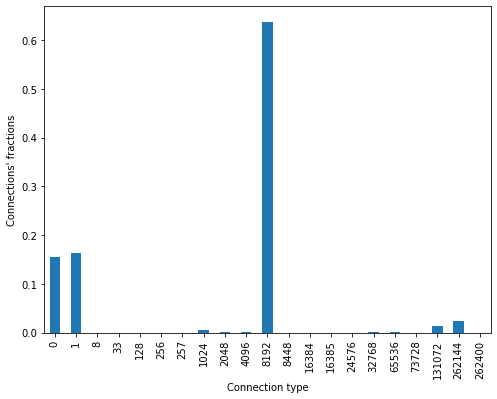

In [14]:
barplot = res.plot(kind="bar", figsize=(8, 6), xlabel="Connection type", ylabel="Connections' fractions")

## Exercise 4

#### Divide the rows of the file in sequential groups of 100000 connections (or smaller when not working on the whole trace). Do not use any filter on local client or service. Count the fraction of HTTP flows for each of these groups. Then plot the series of these fractions (number of the group on the x-axis, fraction of HTTP connections on the y-axis). 
#### Then report on the previous plot also the fraction of HTTPS connections for each group. 
#### Finally report on the previous plot also the fraction of other protocol flows for each group.

In [1]:
#reading in chunk of 500000 rows
df_toChunk = pd.read_csv("Report 4/log_tcp_complete.xz", sep= " ", iterator=True, chunksize=500000)

#using dictionaries for saving results
dict_to_plot_http={}
dict_to_plot_https={}
dict_to_plot_otherProtocol = {}
i=0

#iterating in chunks
for chunk in df_toChunk:
   
    #counting total 
    connection_type_tot_Chunk = chunk.groupby("con_t:42").size().sum()
    
    connection_http_singleChunk = chunk[chunk["con_t:42"]==1] # filter http
    connection_https_singleChunk = chunk[chunk["con_t:42"]==8192] # filter https
    connection_type_fractions = chunk[(chunk["con_t:42"]!=1) & (chunk["con_t:42"]!=8192)].groupby("con_t:42").size().rename("sum") #filter other protocols
    
    #computing fractions
    res_http = len(connection_http_singleChunk)/connection_type_tot_Chunk
    res_https = len(connection_https_singleChunk)/connection_type_tot_Chunk
    res_otherProtocols = connection_type_fractions/connection_type_tot_Chunk
    
    #filling dictionaries
    dict_to_plot_http[i]=res_http 
    dict_to_plot_https[i]= res_https;
    dict_to_plot_otherProtocol[i]=res_otherProtocols.sum(); #sum of all the other protocols
    i+=1

#selecting labels and values
names_http = list(dict_to_plot_http.keys())
values_http = list(dict_to_plot_http.values())

names_https = list(dict_to_plot_https.keys())
values_https = list(dict_to_plot_https.values())

names_otherProtocol = list(dict_to_plot_otherProtocol.keys())
values_otherProtocol = list(dict_to_plot_otherProtocol.values())

IndentationError: unexpected indent (Temp/ipykernel_4332/268573687.py, line 19)

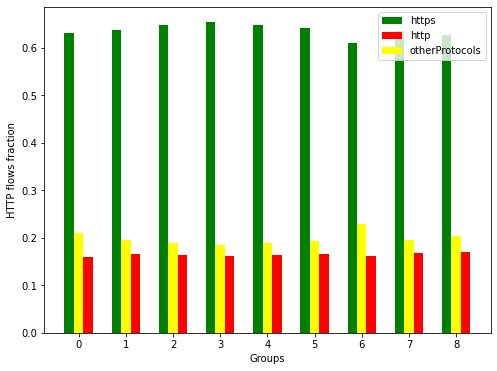

In [16]:
#plotting 
plt.figure(figsize=(8, 6))
X_axis = np.arange(len(values_https))
plt.bar(X_axis - 0.2, values_https, 0.2, tick_label=names_https, color=['green'], label="https")
plt.bar(X_axis + 0.2, values_http, 0.2, tick_label=names_http, color=['red'], label="http")
plt.bar(X_axis, values_otherProtocol, 0.2, tick_label=names_otherProtocol, color=['yellow'], label="otherProtocols")
plt.xlabel("Groups")
plt.ylabel("HTTP flows fraction")
plt.legend(loc="upper right")
plt.show()

#### Comment on the plot. Are there more HTTP or HTTPS flows? Are they stable in time?

There are more HTTPS connections than HTTP and other protocols, because secure connections are the most widely used across the web nowadays. They're pretty much stable in time as we can see from the plot, there's no substantial difference from one chunk to the other.

# Task 2

## Exercise 5

#### Which protocols are used? Count the fraction of connections for different “connection type”. Plot the results as a histogram.

In [17]:
#filtering by assigned web service
df_instagram = df[df["service"].str.contains("instagram")]

#counting total of connection
connection_type_tot = df_instagram.groupby("con_t:42").size().sum()

#extracting used protocols
usedProtocols = df_instagram.groupby("con_t:42").size().index

#computing fractions for each one
connection_type_fractions = df_instagram.groupby("con_t:42").size().rename("sum")
res = connection_type_fractions/connection_type_tot

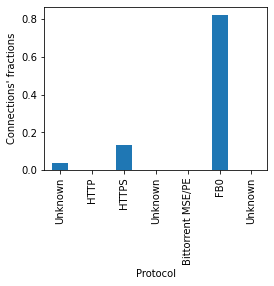

In [18]:
barplot = res.plot(kind="bar", figsize=(4, 3))
plt.xlabel("Protocol")
plt.ylabel("Connections' fractions")
barplot = plt.xticks(range(0,7), ["Unknown", "HTTP", "HTTPS", "Unknown", "Bittorrent MSE/PE", "FB0", "Unknown"])

## Exercise 6

#### Which sub-services are used? [e.g., www.google.com and js.google.com and www.google.it are all subservices of google]. How many are they? What is their name? Plot the total number of connections per each sub-service, ordered by decreasing number of connections (If subservices are more than 20, plot the top-20).

In [19]:
#df_instagram = df[df["service"].str.contains("instagram")]
#grouping by different sub-services
inst_subService = df_instagram.groupby("service").size().rename("sum").sort_values(ascending=False)
print("The number of sub-subservices is: " + str(len(inst_subService)))

The number of sub-subservices is: 186


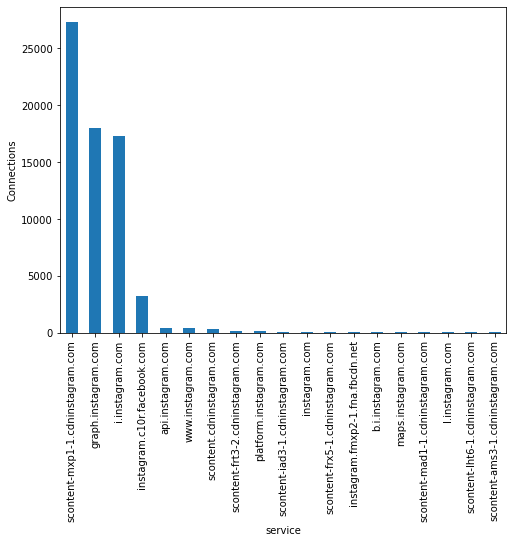

In [20]:
barplot = inst_subService[0:19].plot(kind="bar", figsize=(8, 6), ylabel="Connections")

## Exercise 7

#### Which IP addresses of servers are used? How many are they? Plot the total number of connections per server IP address, ordered by decreasing number of connections (If IP addresses are more than 20, plot the top-20).

In [21]:
#counting IP addresses used
inst_IPServer = df_instagram.groupby('s_ip:15').size().sort_values(ascending=False)
print("The number of IP addresses of servers is: "+ str(len(inst_IPServer)))

The number of IP addresses of servers is: 222


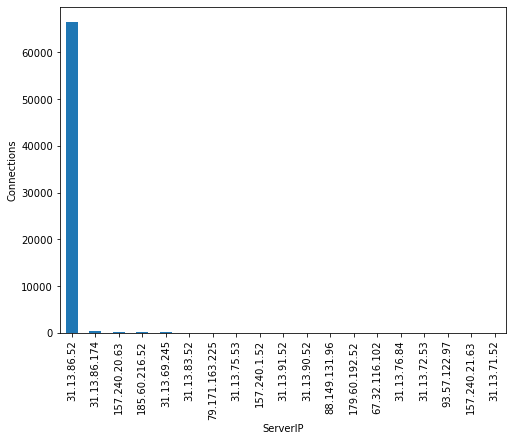

In [22]:
barplot = inst_IPServer[0:19].plot(kind="bar", figsize=(8, 6), xlabel="ServerIP", ylabel="Connections")

## Exercise 8

#### How are sub-services mapped to server IPs? Plot the number of distinct server IPs for each subservice, in decreasing order (If subservices are more than 20, plot the top-20).

In [23]:
#counting the number of different IPs for each subservices
number_IP_per_subservice = df_instagram.groupby(by="service").agg({"s_ip:15": "nunique"}).sort_values(by="s_ip:15", ascending=False)

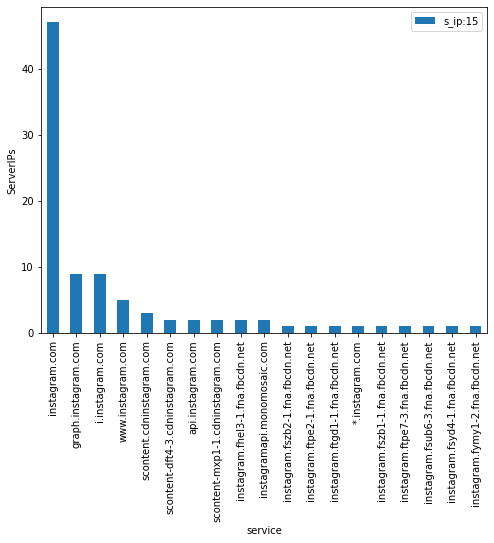

In [24]:
barplot = number_IP_per_subservice[0:19].plot(kind="bar", figsize=(8, 6), ylabel="ServerIPs")

#### How are IPs mapped to sub-services? Plot the number of distinct sub-services for each server IP, in decreasing order (If server IPs are more than20, plot the top-20).

In [25]:
#counting the number of different sub-services for each IP server
number_IP_per_subservice = df_instagram.groupby(by="s_ip:15").agg({"service": "nunique"}).sort_values(by="service", ascending=False)

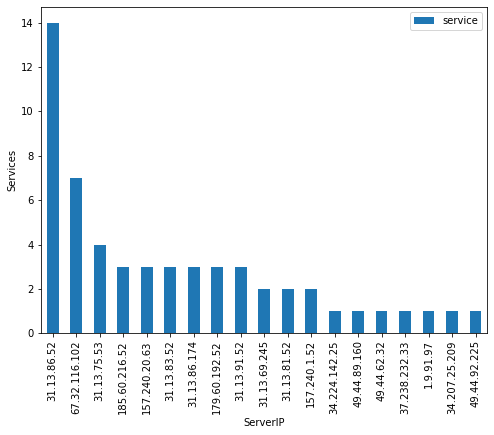

In [26]:
barplot = number_IP_per_subservice[0:19].plot(kind="bar", figsize=(8, 6), xlabel="ServerIP", ylabel="Services")

#### Let’s discuss why there is more than one server IP address per sub-service. Are they from the same network? Try to find the geolocation of these IP addresses. What is their Autonomous System?

Usually a public service can be reachable through more than one server, because redundancy of resources is needed to handle a large number of users contacting the service form all over the world. Big companies like Instagram  spread servers (actually Facebook servers in this case) in different locations across the globe and try to reach the users as close as they can.

Some of them belong to the same network, like 34.207.25.209, 34.206.8.6, 34.204.20.95, 34.200.33.126, 34.194.149.105; we verified they belong to the 34.192.0.0/10 network, which is located in United States Ashburn Amazon Technologies Inc. in Seattle, and belong to the same Autonomous System, which is AS14618 AMAZON-AES, US.

Some server, as we said, are located in the US, while some of them are in different locations: 31.13.86.52 is in Milan, Italy, and we notice that it is the most frequently contacted, as these requests have been done from Italy; its Autonomous System is AS32934 FACEBOOK. 185.60.216.52 is in Dublin, Ireland, and the AS is the same as the previous server (AS32934, FACEBOOK). 

## Exercise 9

#### Plot the total number of connections per each combination of sub-service and server IP. (If the combinations are more than 30, plot the top-30)

In [27]:
numberOfConnections_per_IPServer_Subservice = df_instagram.groupby(["service", "s_ip:15"]).size().sort_values(ascending=False)

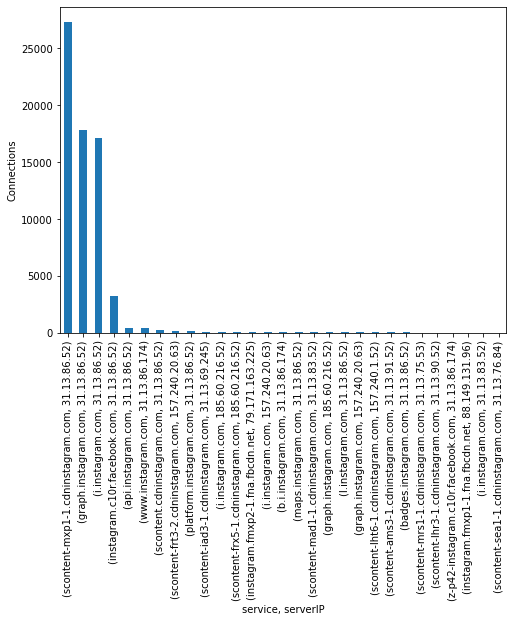

In [28]:
barplot = numberOfConnections_per_IPServer_Subservice[0:29].plot(kind="bar", figsize=(8, 6), xlabel="service, serverIP", ylabel="Connections")

## Exercise 10

#### How many distinct clients access the service in total?

In [29]:
print("The number of distinct clients accessing the service is : " + str(df_instagram["#15#c_ip:1"].nunique()))

The number of distinct clients accessing the service is : 105


#### How many distinct clients access each server IP address ? Plot in decreasing order the number of clients for each IP server address (If server IPs are more than 20, plot the top-20).

In [30]:
numberOfClients_per_IPServer = df_instagram.groupby(["s_ip:15"]).agg({"#15#c_ip:1": "nunique"}).sort_values(by="#15#c_ip:1", ascending=False)

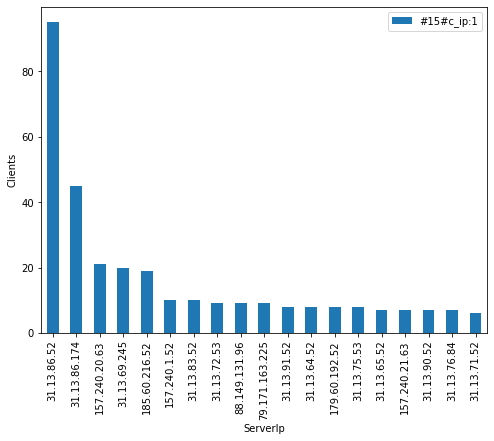

In [31]:
barplot = numberOfClients_per_IPServer[0:19].plot(kind="bar", figsize=(8, 6), xlabel="ServerIp", ylabel="Clients")

#### How many distinct clients access each subservice? Plot in decreasing order the number of clients for each subservice (If subservices are more than 20, plot the top-20).

In [32]:
#counting the number of distinct clients for each subservices
numberOfClients_per_service = df_instagram.groupby(["service"]).agg({"#15#c_ip:1": "nunique"}).sort_values(by="#15#c_ip:1", ascending=False)

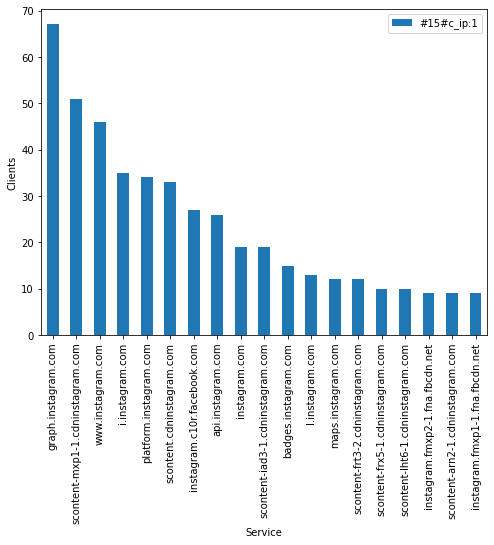

In [33]:
barplot = numberOfClients_per_service[0:19].plot(kind="bar", figsize=(8, 6), xlabel="Service", ylabel="Clients")

## Exercise 11

####  How many bytes were exchanged from the clients to the servers (uplink) in total?

In [34]:
#counting how many bytes sent from each client
totBytes_per_client = df_instagram.groupby(["#15#c_ip:1"]).agg({"c_bytes_all:9": "sum"})
#totBytes_per_client = totPacketsAndBytes_per_client["c_bytes_all:9"].rename("bytes")

#computing the total bytes exchanged in uplink
totBytesFromClients = totBytes_per_client.sum()
print("The total number of bytes exchanged from the clients to the servers is: " + str(totBytesFromClients))

The total number of bytes exchanged from the clients to the servers is: c_bytes_all:9    655769721
dtype: int64


#### How many bytes were exchanged from the servers to the clients (downlink) in total?

In [35]:
#counting how many bytes sent from each server
totBytes_per_server = df_instagram.groupby(["s_ip:15"]).agg({"s_bytes_all:23": "sum"})
#totBytes_per_server = totPacketsAndBytes_per_server["s_bytes_all:23"].rename("bytes")

#computing the toal bytes exchanged in downlink
totBytesFromServer = totBytes_per_server.sum()
print("The total number of bytes exchanged from the servers to the clients is: " + str(totBytesFromServer))

The total number of bytes exchanged from the servers to the clients is: s_bytes_all:23    49460014305
dtype: int64


#### Which fraction of the clients exchanged with the service more than 1MB in total (uplink+downlink)?

In [36]:
totBytes_per_client_up_down = df_instagram.groupby(["#15#c_ip:1"]).agg({"c_bytes_all:9": "sum", "s_bytes_all:23": "sum"})

#computing total number of client
totClients = len(totBytes_per_client_up_down)

#computing uplink + downlink for each client
totBytes = totBytes_per_client_up_down["c_bytes_all:9"] + totBytes_per_client_up_down["s_bytes_all:23"]

#filtering client which sum is greater than 1MB = 1048576 B
filteredClients = totBytes[totBytes > 1048576]

#copmuting and printing fraction
numOfFilteredClients = len(filteredClients)
print("The fraction of the clients which exchanged more than 1MB in total with the service is: " + str(round(numOfFilteredClients/totClients, 2)))

The fraction of the clients which exchanged more than 1MB in total with the service is: 0.39


## Exercise 12

#### Count the total number of bytes handled by each server IP address. Compute this separately for the uplink (client to server) and the downlink (server to client). Plot these two metrics, ordered by decreasing number of bytes (If server IPs are more than 20, plot the top-20).

In [37]:
#computing bytes exchanged both in up and down
totBytes_per_server_up_down = df_instagram.groupby(["s_ip:15"]).agg({"c_bytes_all:9": "sum", "s_bytes_all:23": "sum"})

#uplink
totBytes_per_server_uplink = totBytes_per_server_up_down["c_bytes_all:9"].rename("uplink_bytes").sort_values(ascending=False)


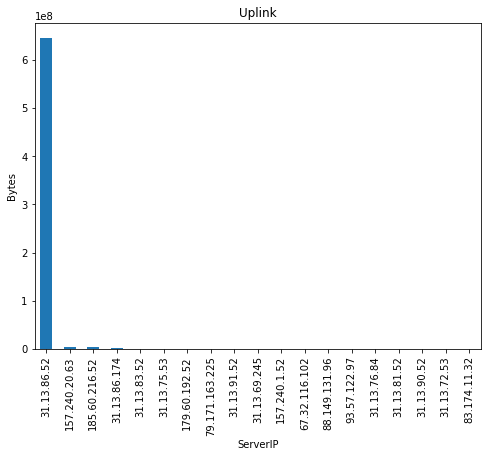

In [38]:
barplot = totBytes_per_server_uplink[0:19].plot(kind="bar", figsize=(8, 6), xlabel="ServerIP", ylabel="Bytes", title="Uplink")


In [39]:
#downlink
totBytes_per_server_downlink = totBytes_per_server_up_down["s_bytes_all:23"].rename("downlink_bytes").sort_values(ascending=False)


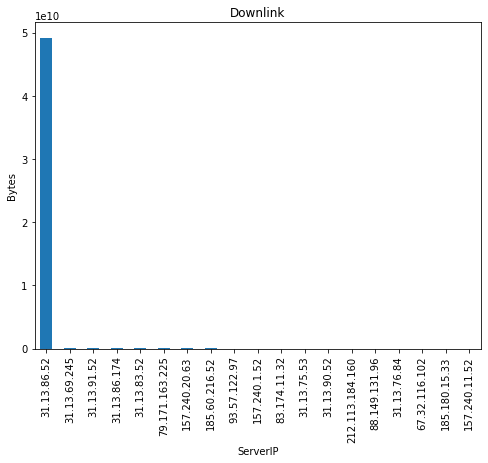

In [40]:
barplot = totBytes_per_server_downlink[0:19].plot(kind="bar", figsize=(8, 6), xlabel="ServerIP", ylabel="Bytes", title="Downlink")


#### Repeat the same for sub-services.

In [41]:
#same step as above, using service column
totBytes_per_service_up_down = df_instagram.groupby(["service"]).agg({"c_bytes_all:9": "sum", "s_bytes_all:23": "sum"})

totBytes_per_service_uplink = (totBytes_per_service_up_down["c_bytes_all:9"]).rename("uplink_bytes").sort_values(ascending=False)


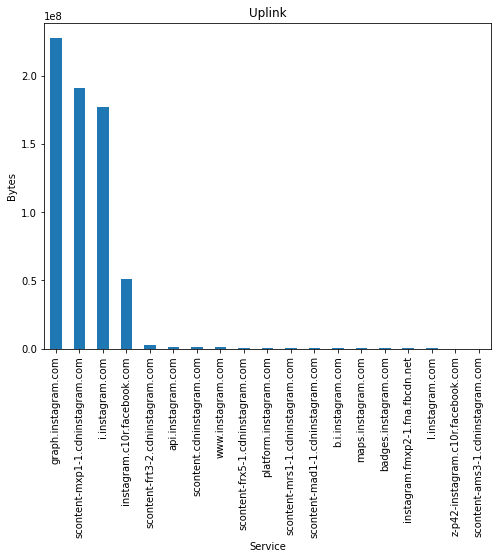

In [42]:
barplot = totBytes_per_service_uplink[0:19].plot(kind="bar", figsize=(8, 6), xlabel="Service", ylabel="Bytes", title="Uplink")


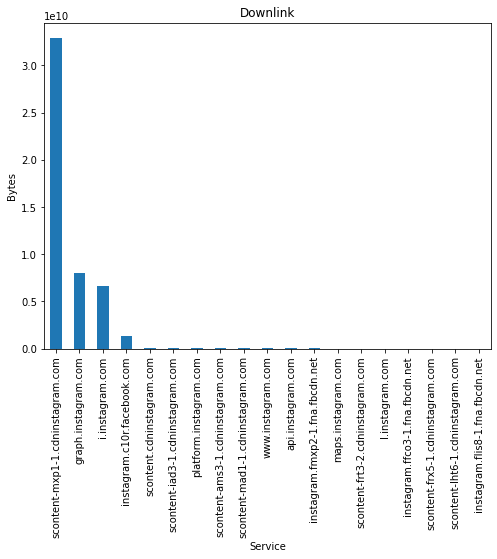

In [44]:
totBytes_per_service_downlink = (totBytes_per_service_up_down["s_bytes_all:23"]).rename("downlink_bytes").sort_values(ascending=False)
barplot = totBytes_per_service_downlink[0:19].plot(kind="bar", figsize=(8, 6), xlabel="Service", ylabel="Bytes", title="Downlink")

## Exercise 13

####  For each server IP, extract the minimum of the minimum RTT and average of the average RTT from the client to the server. Plot them, sorted from the one handling the most clients (see exercise 10), to the least. (If server IPs are more than 20, plot the top-20)

In [45]:
minRTT_per_server = df_instagram.groupby(["s_ip:15"]).agg({"c_rtt_min:46": "min", "#15#c_ip:1": "nunique"}).sort_values(by="#15#c_ip:1", ascending=False)


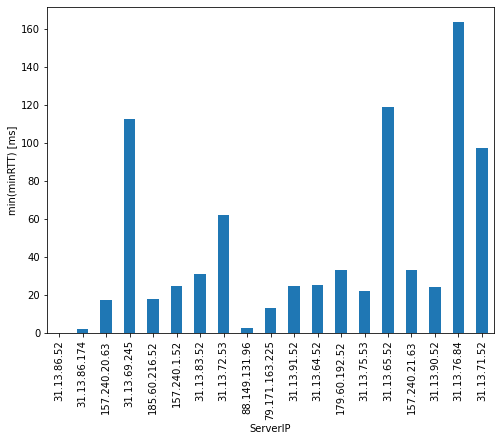

In [46]:
barplot= minRTT_per_server["c_rtt_min:46"][0:19].plot(kind="bar", figsize=(8, 6), xlabel="ServerIP", ylabel="min(minRTT) [ms]")


In [47]:
avgRTT_per_server = df_instagram.groupby(["s_ip:15"]).agg({"c_rtt_avg:45": "mean", "#15#c_ip:1": "nunique"}).sort_values(by="#15#c_ip:1", ascending=False)


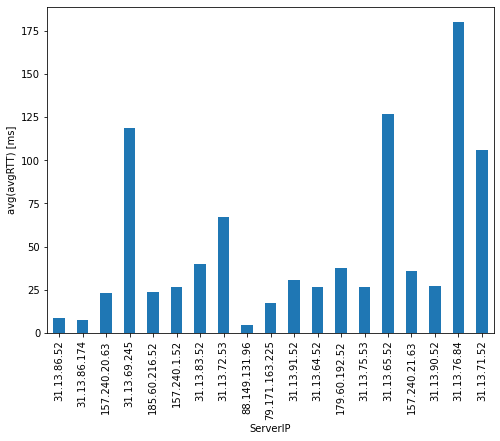

In [48]:
barplot= avgRTT_per_server["c_rtt_avg:45"][0:19].plot(kind="bar", figsize=(8, 6), xlabel="ServerIP", ylabel="avg(avgRTT) [ms]")


#### Can you estimate at which distance the servers are? How?

Yes, we can estimate it from the information about the RTT (there will be an aproximation because we're considering either the minimum or the average RTT); we can do it considering half the RTT (the time needed to reach the server) and multiplying it times the speed of propagation of the signal (200000 km/s). 
Unfortunately, the distances we obtain if we make this computation considering the values we obtain (shown in the plot) are not consistent, as the resulting distances are too high. This could be caused by the fact that there are many outliers (maybe due to TCP retransmissions).

## Exercise 14

#### Plot a scatter plot, considering a point for each sub-service, characterized by the number of connections and the number of exchanged bytes each. 

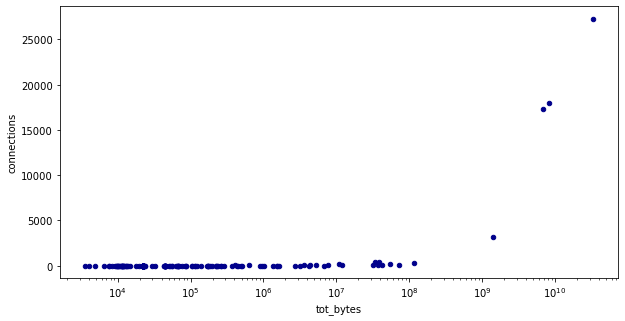

In [49]:
#sub-service(point), number of connections of each subservices, number of exchanged bytes each subservice
#counting the number of connections subservices
inst_subservices_conn = df_instagram.groupby('service').size()

#counting the number of total bytes exchanged (client+server) for each subservice
totBytes_per_subservice = (totBytes_per_service_up_down["s_bytes_all:23"] + totBytes_per_service_up_down["c_bytes_all:9"]).rename("tot_bytes")

#create dataframe for scatter plot
df_scatter = totBytes_per_subservice.to_frame()
df_scatter['connections']=inst_subservices_conn.values

#plotting dataframe
scatter_plot = df_scatter.plot.scatter(x='tot_bytes',y='connections',c='DarkBlue',figsize=(10, 5), logx=True)

#pd.set_option('display.max_rows', None)
#print(df_scatter.sort_values(by='connections', ascending=False))


#### Are there subservices that handle a lot of connections, but little data? Comment on the plot (you might use log scale for the bytes).
Looking at the plot there is no such a evidence. The trend is quite regular, more connections a subservice handles, more bytes it exchanges. But if we look at the data structure used for scatter plot, there are subservices that handle several connections but relatively little data. For instance, the subservices "api.instagram.com" and "instagram.com" handle 388 and 386 connections, respectively. Comparing the data exchanged by these ones with "scontent.cdninstagram.com" subservice (with 298 connections), there is one order of magnitude of difference (few dozens of MB against a hundred of MB). This difference is probably due to the fact that the first two mentioned subservices are used just as interface for the service. So, such subservices exchange only service data and not content data (photo, video), which are the most numerous in terms of bytes exchanged.

*The lines of code used for making above considerations are commented*

## Exercise 15

#### Plot a heatmap representing the number of bytes exchanged between the top-20 most active clients (in terms of number of connections) and the top-20 most contacted sub-services (in terms of number of connections). Select a proper colormap and scale and annotate the cells with whole numbers. Comment on the plot.

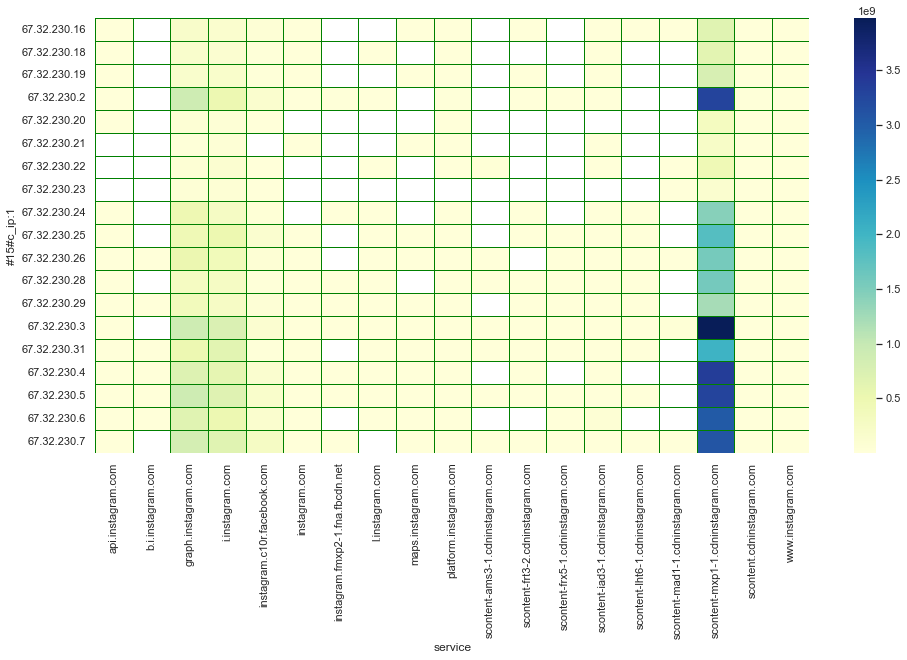

In [50]:
#counting the number of connections for each subservices
inst_subservices_conn = df_instagram.groupby('service').size().sort_values(ascending=False)[0:19]
#print(inst_subservices_conn.index)

#counting the number of connections for each client
inst_client_conn = df_instagram.groupby('#15#c_ip:1').size().sort_values(ascending=False)[0:19]

#filtering
df_sub=df_instagram.loc[df_instagram["#15#c_ip:1"].isin(inst_client_conn.index) & df_instagram["service"].isin(inst_subservices_conn.index),['#15#c_ip:1','c_bytes_all:9','s_bytes_all:23','service']]

#creating a column with total number of bytes exchanged
df_sub['tot_bytes'] = df_sub['c_bytes_all:9'] + df_sub['s_bytes_all:23']

#creating table 20x20
table = pd.pivot_table(df_sub, values='tot_bytes', index=['#15#c_ip:1'], columns='service', aggfunc=np.sum)


#creating heatmap
sns.set(rc={'figure.figsize':(16,8)})
heatmap = sns.heatmap(table, cmap="YlGnBu", linewidths=.5, linecolor='green')
heatmap.set_facecolor('xkcd:white')


From the heatmap, it is obvious that the service "scontent-mxp1-1.cdninstagram.com" exchanges the gratest number of bytes with the clients. In particular, client 67.32.230.3 is the one who is the most active in terms of bytes exchanged. Making a reverse look-up, we see that the ip address of this service is 31.13.86.52. So the previous considerations regarding the activity of this server can be applied.

## Exercise 16

#### For each sub-service, plot a boxplot of the distribution of the fraction of retransmitted packets from the client to the server and vice-versa.

In [51]:
#creating a dictionary in which keys are services and values are lists of values of bytes retransmitted
dictionary = {}
for service in df_instagram["service"].unique():
    dictionary[service] = []
    for bytes_value in df_instagram[df_instagram["service"]==service]["c_bytes_retx:11"]:
        dictionary[service].append(bytes_value)

In [52]:
#creating two lists needed for box-plot: one for keys (lista for axis x) and one for list of values of each service (listanomi axis y)
lista = []
listanomi = []
for key in dictionary.keys():
    lista.append(dictionary[key])
    listanomi.append(key)

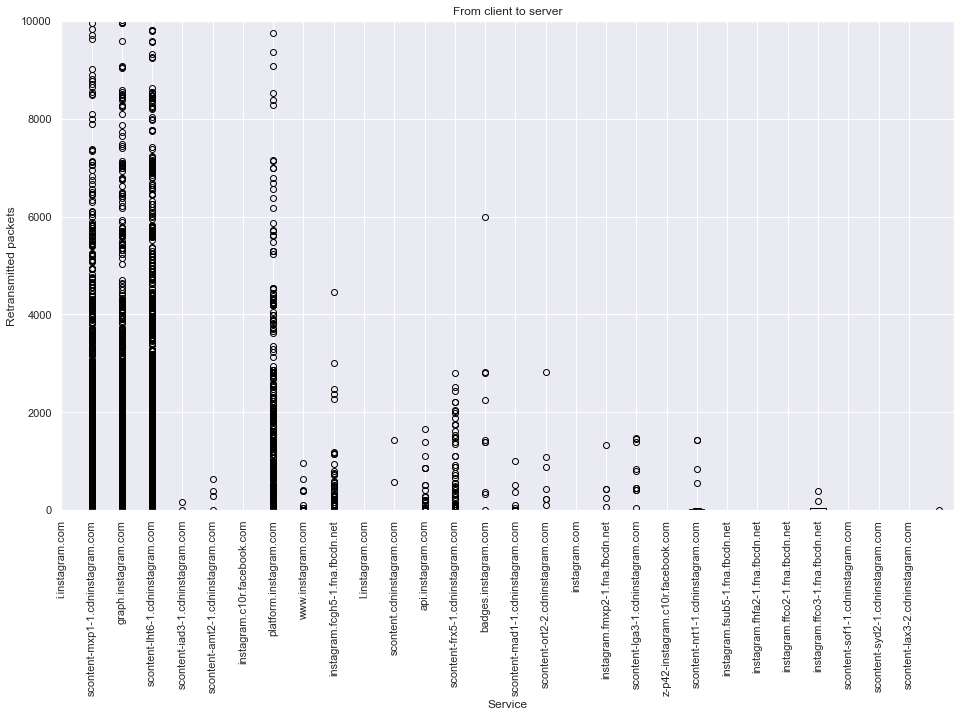

In [53]:
#plotting box-plot
plt.figure(figsize=(16, 9))
boxplot = plt.boxplot(lista[0:29])
plt.title("From client to server")
plt.xlabel("Service")
plt.ylabel("Retransmitted packets")
ticks = plt.xticks(np.arange(0, len(listanomi[0:29]), step=1), listanomi[0:29], rotation='vertical')
lim = plt.ylim(0, 10000)

In [54]:
#same algorithm as above
dictionary = {}
for service in df_instagram["service"].unique():
    dictionary[service] = []
    for bytes_value in df_instagram[df_instagram["service"]==service]["s_bytes_retx:25"]:
        dictionary[service].append(bytes_value)

In [55]:
lista = []
listanomi = []
for key in dictionary.keys():
    lista.append(dictionary[key])
    listanomi.append(key)

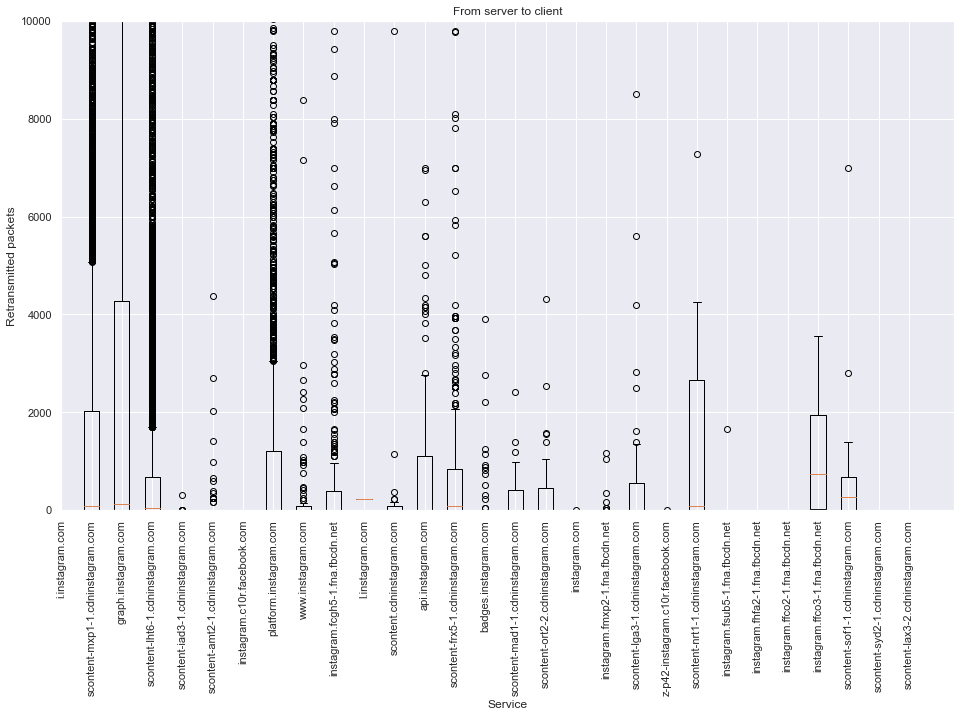

In [56]:
plt.figure(figsize=(16, 9))
boxplot = plt.boxplot(lista[0:29])
plt.title("From server to client")
plt.xlabel("Service")
plt.ylabel("Retransmitted packets")
ticks = plt.xticks(np.arange(0, len(listanomi[0:29]), step=1), listanomi[0:29], rotation='vertical')
lim = plt.ylim(0, 10000)

#### Is there a sub-service with a lot of retransmitted packets? What could be possible reasons for a large number of retransimissions?

A sub-service like graph.instagram.com has a lot of retransmissions, probably because it provides graphical content and for the client it's better to have good quality images, without any frame missing, even if it means some additional delay. 
Retransmissions are triggered when TCP doesn't receive an ACK, which could be caused by network congestions, general problems in the network which result in the drop of the packet (TTL exceeded etc..), damage in the received packets detected by the receiver and so on.

### Exercise 17
#### Draw the empirical Probability Distribution Function (PDF) and the empirical Cumulative Distribution Function (CDF) of the RTT (server to client, you can choose between minimum, average or maximum). The PDF should be estimated either with a histogram or with a proper density estimation. The CDF should be computed precisely (see lecture slides).

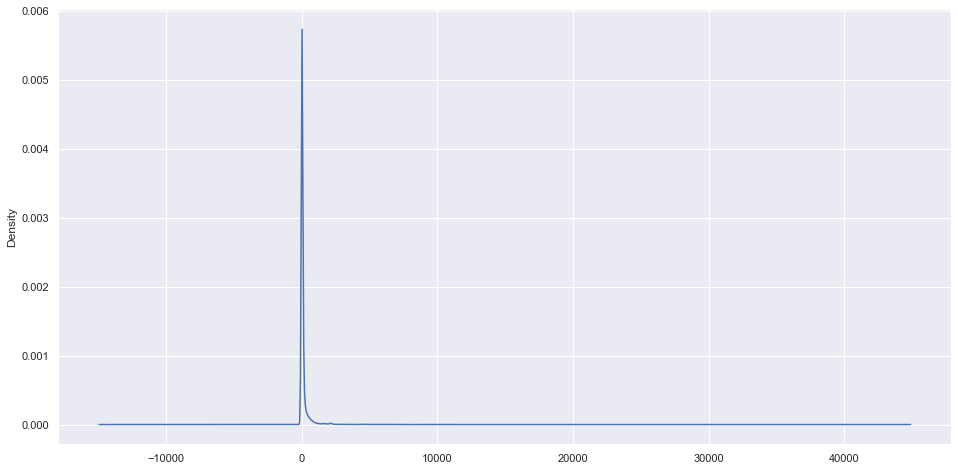

In [59]:
#pdf on average_RTT using density estimation
kdeplot = df_instagram["s_rtt_avg:52"].sort_values(ascending=True).plot.kde()

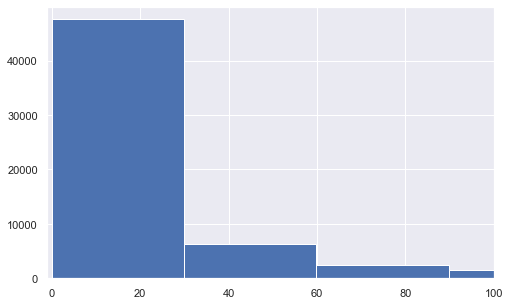

In [63]:
#pdf on average_RTT using histogram
histo = df_instagram["s_rtt_avg:52"].hist(bins=1000, figsize=(8,5))
histo = plt.xlim(-1,100)

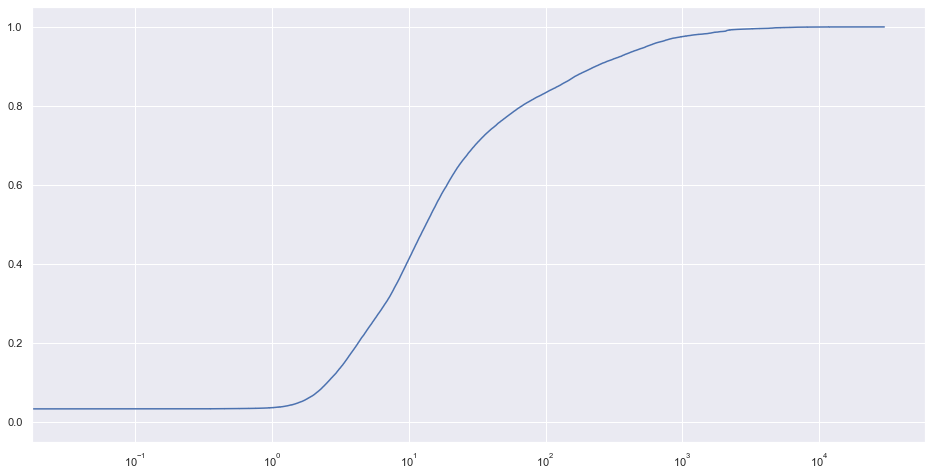

In [65]:
#cdf

#value for x axis
int_val = df_instagram["s_rtt_avg:52"].sort_values(ascending=True).values

cum_dist = np.linspace(0.,1.,len(int_val)) 

#creating series
int_val_cdf = pd.Series(cum_dist, index=int_val) 

#plotting
stepsplot = int_val_cdf.plot(drawstyle='steps',logx = True)

## Exercise 18 - bonus track

#### Play with the other columns. Which analysis do you think would be interesting? (I) Propose some analyses, (ii) show its results, (iii) comment on the findings

We decided to analyse the number of SYN packets for each client, namely how many TCP connection clients established with the services considered (the Instagram ones).
There are certain clients like 67.32.230.20 which connected to Instagram services multiple times, which probably means that they have been using Instagram (scrolling the feed, sending/receiving messages and receiving notifications) for a consistent amount of time during the traffic capturing.

(All the clients shown in this plot are internal Politecnico users, which actually use the internal IP private addressing, but Tstat developers decided to change the addresses shown in the log for privacy issues)

In [66]:
SYN_per_client = df_instagram.groupby(["#15#c_ip:1"]).agg({"c_syn_cnt:13": "sum"}).sort_values(by="c_syn_cnt:13", ascending=False)

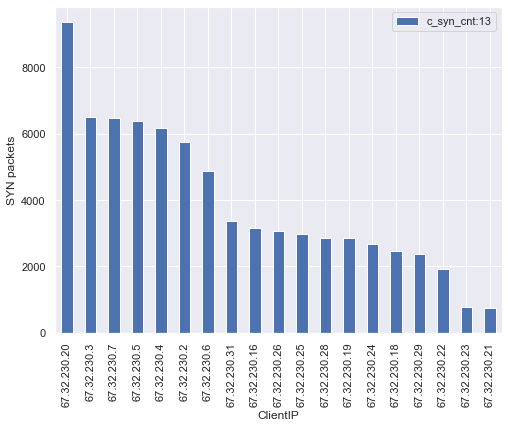

In [67]:
barplot = SYN_per_client[0:19].plot(kind="bar", figsize=(8, 6), xlabel="ClientIP", ylabel="SYN packets")

In [69]:
SYN_per_server = df_instagram.groupby(["s_ip:15"]).agg({"c_syn_cnt:13": "sum"}).sort_values(by="c_syn_cnt:13", ascending=False)

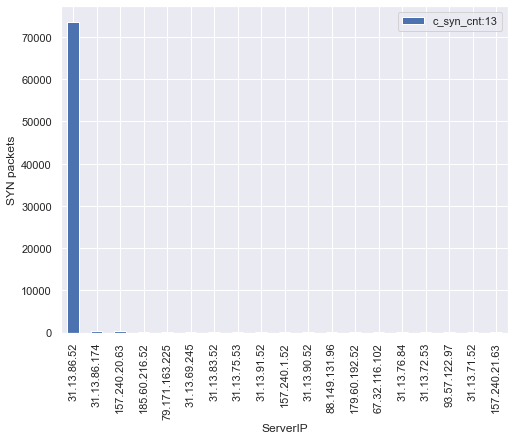

In [70]:
barplot = SYN_per_server[0:19].plot(kind="bar", figsize=(8, 6), xlabel="ServerIP", ylabel="SYN packets")

In this plot we considered the number of SYN packets sent by clients detected for each server IP address.

It is quite clear that the server located in Milan is actually the only one contacted (if we neglet some sporadic SYN packets sent to the other servers) from users in Politecnico, because it can basically provide all the content consumed by the users (it probably goes like this for all Italian clients, they refer to the Milan server).

Furthermore, we notice that connections are always opened by clients; indeed, as we can see in this data:

In [75]:
a = df_instagram.groupby("s_ip:15")["c_syn_cnt:13"].sum().sort_values(ascending=False)[:20]
b = df_instagram.groupby("s_ip:15")["s_syn_cnt:27"].sum().sort_values(ascending=False)[:20]
pd.concat([a, b], axis=1)

,c_syn_cnt:13,s_syn_cnt:27
s_ip:15,,
31.13.86.52,73591.0,79587.0
31.13.86.174,466.0,467.0
157.240.20.63,294.0,317.0
185.60.216.52,200.0,203.0
79.171.163.225,116.0,126.0
31.13.69.245,96.0,96.0
31.13.83.52,90.0,99.0
31.13.75.53,41.0,41.0
31.13.91.52,40.0,41.0


The number of SYN packets sent by servers nearly equals the ones sent by clients, which means that the first ones are all SYN/ACK packets, which reply to the SYNs sent by clients. The only differences in the numbers shown are caused by the occasional TCP retransmissions.